### В этом блокноте проводится EDA для корпуса данных NNCES для построения основных зависимостей и распределений

Импорт библиотек

In [1]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import seaborn as sns
import librosa
from pathlib import Path
import random
import shutil

Загрузка датасета

In [ ]:
base_path = './nonnative-children-english-speech-nnces-corpus/versions/1/Read_Speech_Data/Read_Speech_Data/'

speakers_data = []
all_wav_files = []
all_durations = []

# Парсим структуру NNCES
for age_folder in Path(base_path).iterdir():
    if age_folder.is_dir() and age_folder.name.endswith('Y'):
        try:
            age = int(age_folder.name.replace('Y', ''))
        except ValueError:
            continue
        
        # Проходим по папкам Boys_X и Girls_X
        for gender_age_folder in age_folder.iterdir():
            if gender_age_folder.is_dir():
                folder_name = gender_age_folder.name.lower()
                if 'boy' in folder_name:
                    gender = 'M'
                elif 'girl' in folder_name:
                    gender = 'F'
                else:
                    continue
                
                for participant_folder in gender_age_folder.iterdir():
                    if participant_folder.is_dir() and len(participant_folder.name) >= 2:
                        speaker_code = participant_folder.name
                        
                        # Ищем ВСЕ .wav файлы рекурсивно в папке участника и всех подпапках
                        wav_files = list(participant_folder.rglob('*.wav'))
                        
                        if wav_files:
                            speakers_data.append({
                                'Speaker_ID': speaker_code,
                                'Age': age,
                                'Gender': gender,
                                'Num_Recordings': len(wav_files)
                            })
                            
                            all_wav_files.extend(wav_files)
                            
                            # Теперь собираем длительности ВСЕХ файлов
                            for wav_file in wav_files:
                                try:
                                    duration = librosa.get_duration(path=wav_file)
                                    all_durations.append(duration)
                                except Exception as e:
                                    print(f"Ошибка чтения {wav_file}: {e}")

# Создаем DataFrame
df_nnces = pd.DataFrame(speakers_data)

In [3]:
df_nnces.head()

,Speaker_ID,Age,Gender,Num_Recordings
0,M13,10,M,100
1,M11,10,M,100
2,M12,10,M,100
3,M15,10,M,100
4,M14,10,M,100


Статистика по возрастам

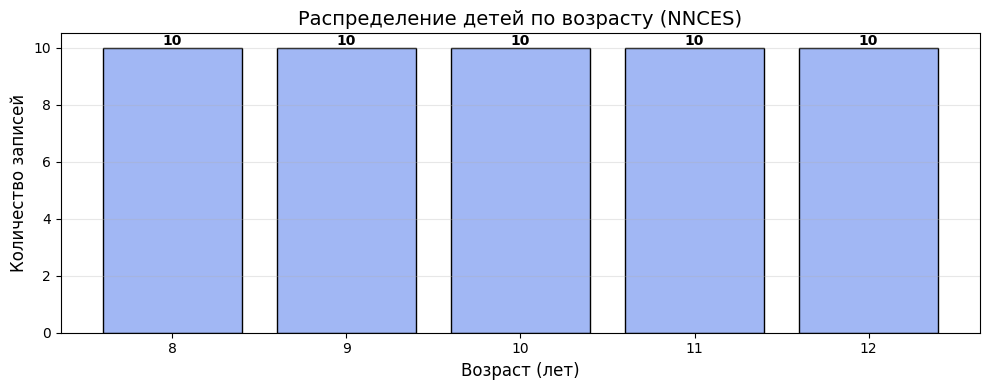

СТАТИСТИКА NNCES: РАСПРЕДЕЛЕНИЕ ПО ВОЗРАСТАМ

Всего уникальных детей: 50
Возрастной диапазон: 8-12 лет
Средний возраст: 10.0 лет
Медианный возраст: 10.0 лет

Детали по возрастам:
  8 лет: 10 детей (20.0%)
  9 лет: 10 детей (20.0%)
  10 лет: 10 детей (20.0%)
  11 лет: 10 детей (20.0%)
  12 лет: 10 детей (20.0%)


In [19]:
plt.figure(figsize=(10, 4))

# В NNCES возраст дискретный (8-12 лет)
age_counts = df_nnces['Age'].value_counts().sort_index()

plt.bar(age_counts.index, age_counts.values, color='#A1B7F4', edgecolor='black')
plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.title('Распределение детей по возрасту (NNCES)', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(age_counts.index)

# Добавляем значения на столбцы
for age, count in age_counts.items():
    plt.text(age, count + 0.001, str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Статистика по возрастам
print("СТАТИСТИКА NNCES: РАСПРЕДЕЛЕНИЕ ПО ВОЗРАСТАМ\n")
print(f"Всего уникальных детей: {df_nnces['Speaker_ID'].nunique()}")
print(f"Возрастной диапазон: {df_nnces['Age'].min()}-{df_nnces['Age'].max()} лет")
print(f"Средний возраст: {df_nnces['Age'].mean():.1f} лет")
print(f"Медианный возраст: {df_nnces['Age'].median():.1f} лет")

print("\nДетали по возрастам:")
for age, count in age_counts.items():
    percent = count / len(df_nnces) * 100
    print(f"  {age} лет: {count} детей ({percent:.1f}%)")


Статистика по полу

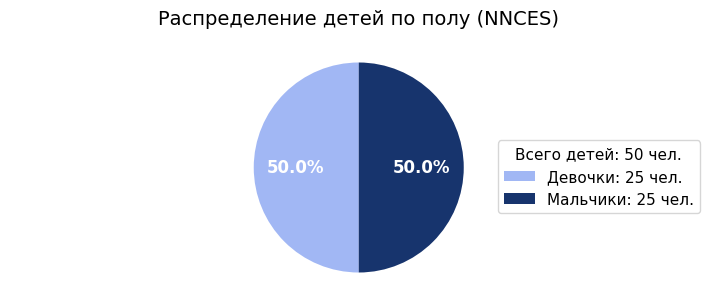


СТАТИСТИКА ПО ПОЛУ:
Девочек (F): 25 (50.0%)
Мальчиков (M): 25 (50.0%)


In [20]:
gender_counts = df_nnces['Gender'].value_counts()

plt.figure(figsize=(9, 3))
colors = ['#A1B7F4', "#17346D"]  # Розовый и бирюзовый

wedges, texts, autotexts = plt.pie(gender_counts.values, 
                                    labels=None,
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    textprops={'fontsize': 12, 'color': 'white', 'fontweight': 'bold'})

plt.legend(wedges, 
           [f'Девочки: {gender_counts.get("F", 0)} чел.', 
            f'Мальчики: {gender_counts.get("M", 0)} чел.'],
           loc='upper right',
           bbox_to_anchor=(1, 0.65),
           frameon=True,
           fontsize=11,
           title=f'Всего детей: {len(df_nnces)} чел.',
           title_fontsize=11)

plt.title('Распределение детей по полу (NNCES)', loc='center', fontsize=14, pad=20)
plt.axis('equal')
plt.show()

# Статистика по полу
print(f"\nСТАТИСТИКА ПО ПОЛУ:")
print(f"Девочек (F): {gender_counts.get('F', 0)} ({gender_counts.get('F', 0)/len(df_nnces)*100:.1f}%)")
print(f"Мальчиков (M): {gender_counts.get('M', 0)} ({gender_counts.get('M', 0)/len(df_nnces)*100:.1f}%)")

Распределение длительностей


Обнаружено 5000 аудиофайлов для анализа


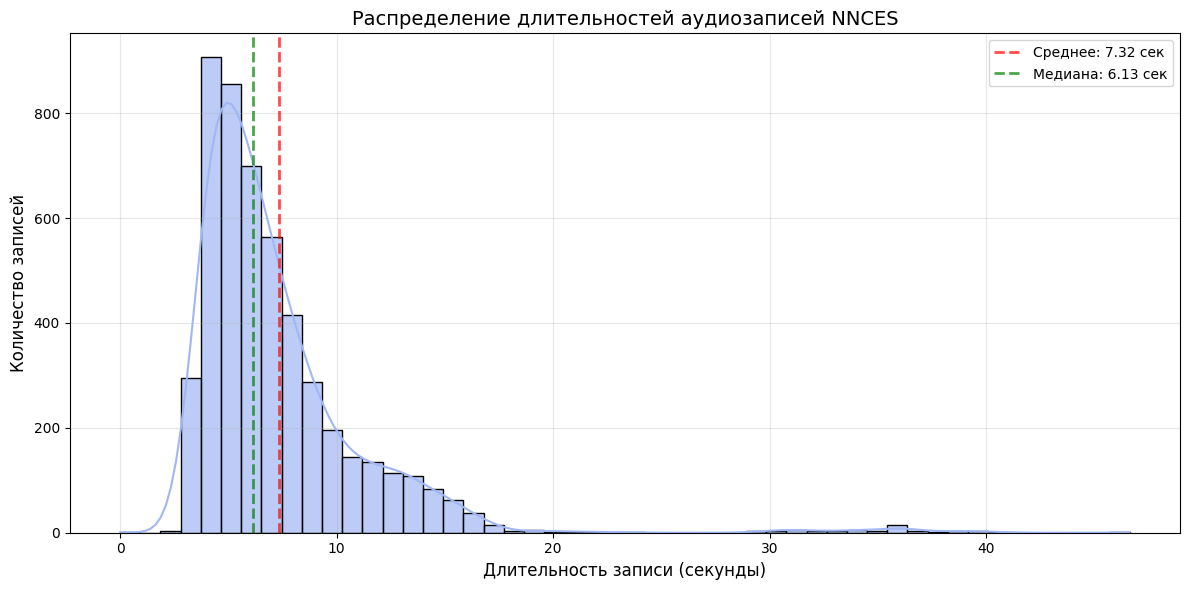

Распределение длительностей записей NNCES

Минимальная длительность: 0.00 сек
Максимальная длительность: 46.63 сек
Средняя длительность: 7.32 сек
Медианная длительность: 6.13 сек
Стандартное отклонение: 4.31 сек


In [21]:
print(f"\nОбнаружено {len(all_durations)} аудиофайлов для анализа")

plt.figure(figsize=(12, 6))

# Гистограмма с KDE
sns.histplot(all_durations, bins=50, kde=True, color='#A1B7F4', alpha=0.7)
plt.xlabel('Длительность записи (секунды)', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.title('Распределение длительностей аудиозаписей NNCES', fontsize=14)
plt.grid(True, alpha=0.3)

# Добавляем вертикальные линии для статистики
mean_dur = np.mean(all_durations)
median_dur = np.median(all_durations)

plt.axvline(mean_dur, color='red', linestyle='--', linewidth=2, alpha=0.7, 
            label=f'Среднее: {mean_dur:.2f} сек')
plt.axvline(median_dur, color='green', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Медиана: {median_dur:.2f} сек')

plt.legend()
plt.tight_layout()
plt.show()

# Статистика по длительностям
print("Распределение длительностей записей NNCES\n")
print(f"Минимальная длительность: {min(all_durations):.2f} сек")
print(f"Максимальная длительность: {max(all_durations):.2f} сек")
print(f"Средняя длительность: {mean_dur:.2f} сек")
print(f"Медианная длительность: {median_dur:.2f} сек")
print(f"Стандартное отклонение: {np.std(all_durations):.2f} сек")



### Выводы
#### При проведении первичного анализа набора данных NNCES были выявлены следующие закономерности:
- Возрастной диапазон колеблется от 8 до 12 лет;
- Набор идеально сбаллансирован как по половому, так и по возрастному критерию;
- При анализе распределения длительностей аудиозаписей выявлено, что средняя продолжительность составляет 7.32 секунды, а сами длительности достигают 46.63 с.

Разделение на тренировочеую и тестовую выборки

In [ ]:
# Пути
base_path = Path('./nonnative-children-english-speech-nnces-corpus/versions/1/Read_Speech_Data/Read_Speech_Data/')
output_base = Path('./nnces_split')

# Создаем выходные директории
train_dir = output_base / 'train'
test_dir = output_base / 'test'
train_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)

# Собираем ВСЕ .wav файлы (с любым регистром расширения)
all_wav_files = list(base_path.rglob('*.[Ww][Aa][Vv]'))
print(f"Найдено {len(all_wav_files)} .wav файлов")

# Перемешиваем случайным образом
random.seed(42)  # Для воспроизводимости
random.shuffle(all_wav_files)

# Разделяем 80/20
split_idx = int(len(all_wav_files) * 0.8)
train_files = all_wav_files[:split_idx]
test_files = all_wav_files[split_idx:]

print(f"\nРазделение:")
print(f"  Train: {len(train_files)} файлов ({len(train_files)/len(all_wav_files)*100:.1f}%)")
print(f"  Test:  {len(test_files)} файлов ({len(test_files)/len(all_wav_files)*100:.1f}%)")

# Копируем файлы в соответствующие папки
def copy_files(files, target_dir):
    for i, src_path in enumerate(files):
        # Сохраняем оригинальную структуру папок внутри train/test
        rel_path = src_path.relative_to(base_path)
        dst_path = target_dir / rel_path
        
        # Создаем директории если нужно
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        
        # Копируем файл
        shutil.copy2(src_path, dst_path)  # copy2 сохраняет метаданные
        
        if (i + 1) % 500 == 0:
            print(f"  Скопировано {i + 1}/{len(files)} файлов...")

print("\nКопируем train файлы...")
copy_files(train_files, train_dir)

print("\nКопируем test файлы...")
copy_files(test_files, test_dir)

print("\n✓ Готово!")
print(f"Train: {train_dir}")
print(f"Test:  {test_dir}")

# Проверяем балансировку по спикерам (опционально)
print("\nБалансировка по спикерам (первые 10):")
speaker_train_counts = {}
speaker_test_counts = {}

for file in train_files:
    # Извлекаем код спикера из пути (например, M11 из .../M11/...)
    for part in file.parts:
        if part.startswith(('M', 'F')) and part[1:].isdigit():
            speaker_train_counts[part] = speaker_train_counts.get(part, 0) + 1
            break

for file in test_files:
    for part in file.parts:
        if part.startswith(('M', 'F')) and part[1:].isdigit():
            speaker_test_counts[part] = speaker_test_counts.get(part, 0) + 1
            break

# Показываем распределение для первых 10 спикеров
for i, (speaker, count) in enumerate(list(speaker_train_counts.items())[:10]):
    test_count = speaker_test_counts.get(speaker, 0)
    total = count + test_count
    if total > 0:
        print(f"  {speaker}: train={count}, test={test_count}, test_ratio={test_count/total*100:.1f}%")

Найдено 5000 .wav файлов

Разделение:
  Train: 4000 файлов (80.0%)
  Test:  1000 файлов (20.0%)

Копируем train файлы...
  Скопировано 500/4000 файлов...
  Скопировано 1000/4000 файлов...
  Скопировано 1500/4000 файлов...
  Скопировано 2000/4000 файлов...
  Скопировано 2500/4000 файлов...
  Скопировано 3000/4000 файлов...
  Скопировано 3500/4000 файлов...
  Скопировано 4000/4000 файлов...

Копируем test файлы...
  Скопировано 500/1000 файлов...
  Скопировано 1000/1000 файлов...

✓ Готово!
Train: /home/ext-ivanova-mk@ad.speechpro.com/ITMO/nnces_split/train
Test:  /home/ext-ivanova-mk@ad.speechpro.com/ITMO/nnces_split/test

Балансировка по спикерам (первые 10):
  F22: train=81, test=19, test_ratio=19.0%
  M23: train=77, test=23, test_ratio=23.0%
  F8: train=82, test=18, test_ratio=18.0%
  M22: train=79, test=21, test_ratio=21.0%
  F10: train=81, test=19, test_ratio=19.0%
  F11: train=79, test=21, test_ratio=21.0%
  M14: train=76, test=24, test_ratio=24.0%
  M15: train=81, test=19, test_r